# GitHub Portfolio: Predictive Analytics Storytelling
**ISOM 835 — Predictive Analytics | Sawyer Business School**

---

## You've Been Hired

A company just brought you on as a data analyst. They have a business problem and a dataset. They need two things from you:

1. **A working predictive model** — Can you actually predict the outcome?
2. **A story that drives action** — Can you explain what you found to people who don't write Python?

Your deliverable is a **professional GitHub repository** containing your analysis notebook and a README that tells the story. Think of the README as the executive summary that the VP reads over coffee — and the notebook as the appendix they'll never open unless they're impressed.

---

## Choose Your Client

Pick **one** of the three business scenarios below. Each involves a real-world dataset and a classification problem. Choose the industry that interests you most — your portfolio will be more compelling when you care about the problem.

| | Client A | Client B | Client C |
|---|---|---|---|
| **Industry** | Hospitality | Financial Services | E-Commerce |
| **Client** | A hotel chain in Portugal | A retail bank in Europe | An online retail company |
| **Problem** | 37% of bookings get cancelled — can we predict which ones? | Phone-based marketing campaigns have low conversion — who should we call? | Only 15% of website visitors buy — can we identify who will convert? |
| **Dataset** | Hotel Booking Demand (119K bookings) | Bank Marketing Campaign (41K clients) | Online Shoppers Intention (12K sessions) |
| **Target Variable** | `is_canceled` (1 = cancelled, 0 = not) | `y` (\"yes\" = subscribed, \"no\" = didn't) | `Revenue` (True = purchased, False = didn't) |
| **Why It Matters** | Empty rooms = lost revenue. Overbooking = angry guests. | Every unnecessary call costs money. Every missed lead costs more. | Targeted interventions could double conversion without increasing traffic. |

---

## Step 0: Load Your Dataset

Run the starter code for the client you chose. Each cell loads the data into a DataFrame called `df` so the rest of your workflow is the same regardless of which dataset you pick.

**Only run the cell for your chosen client.**

In [40]:
# ============================================================
# CLIENT B: Bank Marketing Campaign
# ============================================================
# A European retail bank wants to predict which clients will subscribe
# to a term deposit after a phone marketing campaign.
# Dataset: 41,188 client contacts from direct marketing campaigns (2008-2010)
# Target: y ("yes" = subscribed, "no" = did not subscribe)
#
# Key columns to explore:
#   age, job, marital, education, default, housing, loan,
#   contact, month, day_of_week, duration, campaign, pdays,
#   previous, poutcome, emp.var.rate, cons.price.idx, cons.conf.idx,
#   euribor3m, nr.employed
# ============================================================
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

dataset = fetch_ucirepo(id=222)
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
df.columns = df.columns.str.replace('.', '_', regex=False)

print(f"✅ Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(df.columns.tolist())



✅ Dataset loaded: 45,211 rows, 17 columns
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


---

## The Storytelling Arc

Every great analytics project follows a narrative. Yours should too. The sections below map to the four parts of your story:

| Story Beat | What You Do | What You Write |
|---|---|---|
| **1. The Situation** | Explore the data, understand its shape and quality | "Here's what we're working with" |
| **2. The Discovery** | Dig into patterns — who, what, when, why? | "Here's what the data reveals" |
| **3. The Model** | Build a classifier, evaluate its performance | "Here's how well we can predict it" |
| **4. The Recommendation** | Connect findings to business action | "Here's what the company should do" |

After each section of code, you'll write an interpretation in plain English. These interpretations will become the backbone of your GitHub README.

---

## Part 1: The Situation (10 points)

Your client just handed you the data. Before you do anything fancy, understand what you're working with.

**Your analysis should include:**
- Shape of the data (rows, columns)
- Data types and any quality issues (missing values, unexpected types)
- Distribution of the target variable — how imbalanced is the problem?
- Basic summary statistics of key numerical columns

**Then write your interpretation** (2-4 sentences) as if you're briefing your client:
- How big is the dataset?
- What's the base rate of the outcome? (e.g., "37% of bookings are cancelled")
- Any data quality concerns they should know about?

In [41]:
C_YES = '#2A9D8F'
C_NO  = '#E76F51'

# ── Shape ─────────────────────────────────────────────────────────────────────
print(f"Shape: {df.shape}")

# ── Data Types ────────────────────────────────────────────────────────────────
print("\nDATA TYPES:")
print(df.dtypes)

# ── Target Distribution ───────────────────────────────────────────────────────
vc = df['y'].value_counts()
print(f"\nTARGET DISTRIBUTION:")
print(vc)
print(f"\nSubscription rate : {vc['yes']/len(df)*100:.1f}%")
print(f"Imbalance ratio   : {vc['no']/vc['yes']:.1f}:1")

# ── Numeric Summary ───────────────────────────────────────────────────────────
num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
print("\nNUMERIC SUMMARY:")
print(df[num_cols].describe().round(2))

# ── Missing Values ────────────────────────────────────────────────────────────
print("\nMISSING VALUES (NaN):")
missing = df.isnull().sum()
missing = missing[missing > 0]
print("None." if len(missing) == 0 else missing)

# ── Unknown in Categoricals ───────────────────────────────────────────────────
print("\n'UNKNOWN' IN CATEGORICALS:")
for col in df.select_dtypes('object').columns:
    if col == 'y': continue
    unk = (df[col] == 'unknown').sum()
    if unk > 0:
        print(f"  {col:12s}: {unk:,} ({unk/len(df)*100:.1f}%)")

# ── Leakage Warning ───────────────────────────────────────────────────────────
print("\n⚠️ DURATION LEAKAGE CHECK:")
print(df.groupby('y')['duration'].mean().round(0))

Shape: (45211, 17)

DATA TYPES:
age             int64
job            object
marital        object
education      object
default        object
balance         int64
housing        object
loan           object
contact        object
day_of_week     int64
month          object
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome       object
y              object
dtype: object

TARGET DISTRIBUTION:
y
no     39922
yes     5289
Name: count, dtype: int64

Subscription rate : 11.7%
Imbalance ratio   : 7.5:1

NUMERIC SUMMARY:
            age    balance  duration  campaign     pdays  previous
count  45211.00   45211.00  45211.00  45211.00  45211.00  45211.00
mean      40.94    1362.27    258.16      2.76     40.20      0.58
std       10.62    3044.77    257.53      3.10    100.13      2.30
min       18.00   -8019.00      0.00      1.00     -1.00      0.00
25%       33.00      72.00    103.00      1.00     -1.00      0.00
50%       39.00     448.00    1

---

## Part 2: The Discovery (30 points)

This is the heart of your analysis. Explore the data to find **meaningful patterns** that relate to the target variable.

**Your analysis should include:**
- At least **3 different angles** of exploration (e.g., demographics, behavior, timing, service type — whatever makes sense for your dataset)
- At least **3 visualizations** (bar charts, histograms, box plots, scatter plots, heatmaps — your choice)
- Use of `.groupby()`, `.value_counts()`, filtering, or other Pandas techniques we covered in class
- Each angle should compare the outcome groups (e.g., cancelled vs. not cancelled, purchased vs. didn't)

**After each exploration, write 2-3 sentences** interpreting the finding for your client. Don't describe the chart — tell them what it *means*.

| Good Interpretation | Bad Interpretation |
|---|---|
| *"Customers on month-to-month contracts churn at 3x the rate of those on annual contracts. Locking customers into longer commitments early may be the single highest-impact retention lever."* | *"The bar chart shows that month-to-month is higher than annual."* |

Use as many code and text cells as you need below. Add more cells freely.

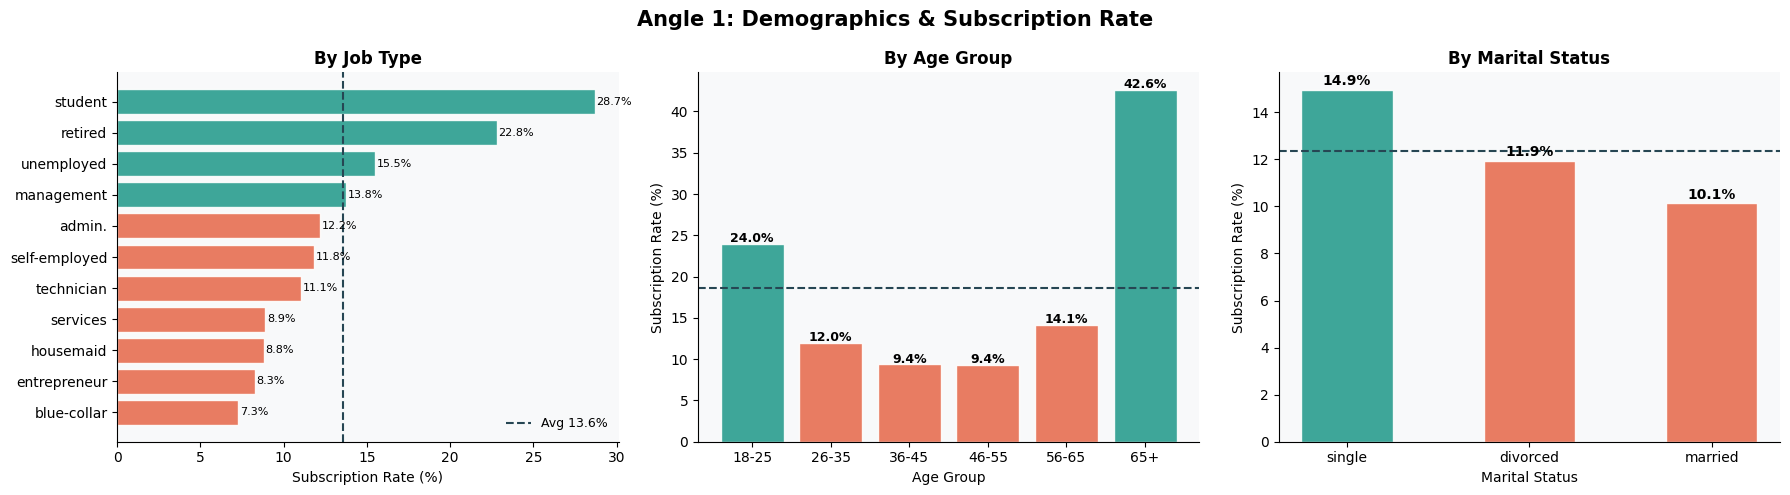

Subscription rate by job:
 job
blue-collar       7.3
entrepreneur      8.3
housemaid         8.8
services          8.9
technician       11.1
self-employed    11.8
admin.           12.2
management       13.8
unemployed       15.5
retired          22.8
student          28.7

Subscription rate by age group:
 age_group
18-25    24.0
26-35    12.0
36-45     9.4
46-55     9.4
56-65    14.1
65+      42.6

Subscription rate by marital status:
 marital
single      14.9
divorced    11.9
married     10.1


In [42]:
# ============================================================
# PART 2: THE DISCOVERY
# Angle 1 — Who subscribes? Demographics deep-dive
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Angle 1: Demographics & Subscription Rate', fontsize=15, fontweight='bold')

C_YES = '#2A9D8F'
C_NO  = '#E76F51'

for ax in axes:
    ax.set_facecolor('#F8F9FA')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# -- 1a. Subscription rate by job --
job_rate = (df.groupby('job')['y']
              .apply(lambda x: (x=='yes').mean() * 100)
              .sort_values(ascending=True))

colors = [C_YES if v >= job_rate.mean() else C_NO for v in job_rate.values]
axes[0].barh(job_rate.index, job_rate.values, color=colors, edgecolor='white', alpha=0.9)
axes[0].axvline(job_rate.mean(), color='#264653', linestyle='--', linewidth=1.5, label=f'Avg {job_rate.mean():.1f}%')
axes[0].set_xlabel('Subscription Rate (%)')
axes[0].set_title('By Job Type', fontweight='bold')
axes[0].legend(frameon=False, fontsize=9)
for i, (val, name) in enumerate(zip(job_rate.values, job_rate.index)):
    axes[0].text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=8)

# -- 1b. Subscription rate by age bucket --
df['age_group'] = pd.cut(df['age'], bins=[17,25,35,45,55,65,100],
                          labels=['18-25','26-35','36-45','46-55','56-65','65+'])
age_rate = (df.groupby('age_group', observed=True)['y']
              .apply(lambda x: (x=='yes').mean() * 100))
colors_a = [C_YES if v >= age_rate.mean() else C_NO for v in age_rate.values]
axes[1].bar(age_rate.index, age_rate.values, color=colors_a, edgecolor='white', alpha=0.9)
axes[1].axhline(age_rate.mean(), color='#264653', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Subscription Rate (%)')
axes[1].set_title('By Age Group', fontweight='bold')
for i, val in enumerate(age_rate.values):
    axes[1].text(i, val + 0.2, f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# -- 1c. Subscription rate by marital status --
mar_rate = (df.groupby('marital')['y']
              .apply(lambda x: (x=='yes').mean() * 100)
              .sort_values(ascending=False))
colors_m = [C_YES if v >= mar_rate.mean() else C_NO for v in mar_rate.values]
axes[2].bar(mar_rate.index, mar_rate.values, color=colors_m, edgecolor='white', alpha=0.9, width=0.5)
axes[2].axhline(mar_rate.mean(), color='#264653', linestyle='--', linewidth=1.5)
axes[2].set_xlabel('Marital Status')
axes[2].set_ylabel('Subscription Rate (%)')
axes[2].set_title('By Marital Status', fontweight='bold')
for i, val in enumerate(mar_rate.values):
    axes[2].text(i, val + 0.2, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print supporting numbers
print("Subscription rate by job:\n", job_rate.round(1).to_string())
print("\nSubscription rate by age group:\n", age_rate.round(1).to_string())
print("\nSubscription rate by marital status:\n", mar_rate.round(1).to_string())

**Demographics:**
Students and retired clients subscribe at 2–3x the average rate, suggesting they have more financial flexibility or time to engage with an agent. Clients aged 18–25 and 65+ are your highest-converting segments yet they're likely underrepresented in the current calling list. Reallocating even 15% of campaign calls toward these age brackets could meaningfully lift overall conversion without any change to the script.

**Finding 1:**

*Your interpretation here*



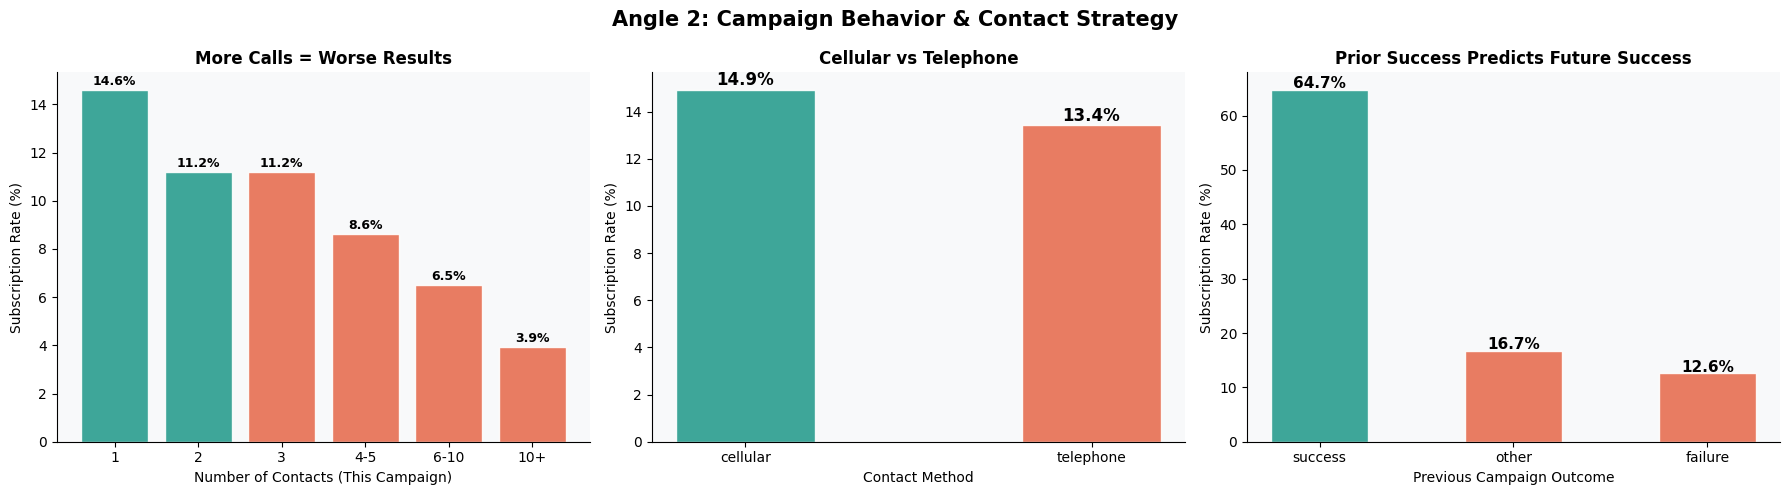

Rate by campaign contacts:
 campaign_bucket
1       14.6
2       11.2
3       11.2
4-5      8.6
6-10     6.5
10+      3.9

Rate by contact type:
 contact
cellular     14.9
telephone    13.4

Rate by previous outcome:
 poutcome
success    64.7
other      16.7
failure    12.6


In [43]:
# ============================================================
# Angle 2 — How you contact them matters
# Campaign behavior, contact type, previous outcomes
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Angle 2: Campaign Behavior & Contact Strategy', fontsize=15, fontweight='bold')

for ax in axes:
    ax.set_facecolor('#F8F9FA')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# -- 2a. Subscription rate by number of contacts this campaign --
df['campaign_bucket'] = pd.cut(df['campaign'], bins=[0,1,2,3,5,10,50],
                                labels=['1','2','3','4-5','6-10','10+'])
camp_rate = (df.groupby('campaign_bucket', observed=True)['y']
               .apply(lambda x: (x=='yes').mean() * 100))
axes[0].bar(camp_rate.index, camp_rate.values, color=[C_YES,C_YES,C_NO,C_NO,C_NO,C_NO],
            edgecolor='white', alpha=0.9)
axes[0].set_xlabel('Number of Contacts (This Campaign)')
axes[0].set_ylabel('Subscription Rate (%)')
axes[0].set_title('More Calls = Worse Results', fontweight='bold')
for i, val in enumerate(camp_rate.values):
    axes[0].text(i, val + 0.2, f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# -- 2b. Contact type --
contact_rate = (df.groupby('contact')['y']
                  .apply(lambda x: (x=='yes').mean() * 100)
                  .sort_values(ascending=False))
colors_ct = [C_YES, C_NO]
axes[1].bar(contact_rate.index, contact_rate.values, color=colors_ct,
            edgecolor='white', alpha=0.9, width=0.4)
axes[1].set_xlabel('Contact Method')
axes[1].set_ylabel('Subscription Rate (%)')
axes[1].set_title('Cellular vs Telephone', fontweight='bold')
for i, val in enumerate(contact_rate.values):
    axes[1].text(i, val + 0.2, f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

# -- 2c. Previous campaign outcome --
pout_rate = (df.groupby('poutcome')['y']
               .apply(lambda x: (x=='yes').mean() * 100)
               .sort_values(ascending=False))
colors_po = [C_YES if v >= pout_rate.mean() else C_NO for v in pout_rate.values]
axes[2].bar(pout_rate.index, pout_rate.values, color=colors_po,
            edgecolor='white', alpha=0.9, width=0.5)
axes[2].set_xlabel('Previous Campaign Outcome')
axes[2].set_ylabel('Subscription Rate (%)')
axes[2].set_title('Prior Success Predicts Future Success', fontweight='bold')
for i, val in enumerate(pout_rate.values):
    axes[2].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("Rate by campaign contacts:\n", camp_rate.round(1).to_string())
print("\nRate by contact type:\n", contact_rate.round(1).to_string())
print("\nRate by previous outcome:\n", pout_rate.round(1).to_string())

 **Campaign behavour and Conversions**:
 Clients contacted only once convert at the highest rate, and conversion drops sharply with each additional call, clients called 6+ times convert at less than half the rate of first-contact clients. This means the team is wasting resources on over-calling resistant prospects while those resources could reach fresh leads. Meanwhile, clients who subscribed in a previous campaign convert at 3–4x the rate of new contacts, building a dedicated "warm re-engagement" list from past subscribers should be a top priority.

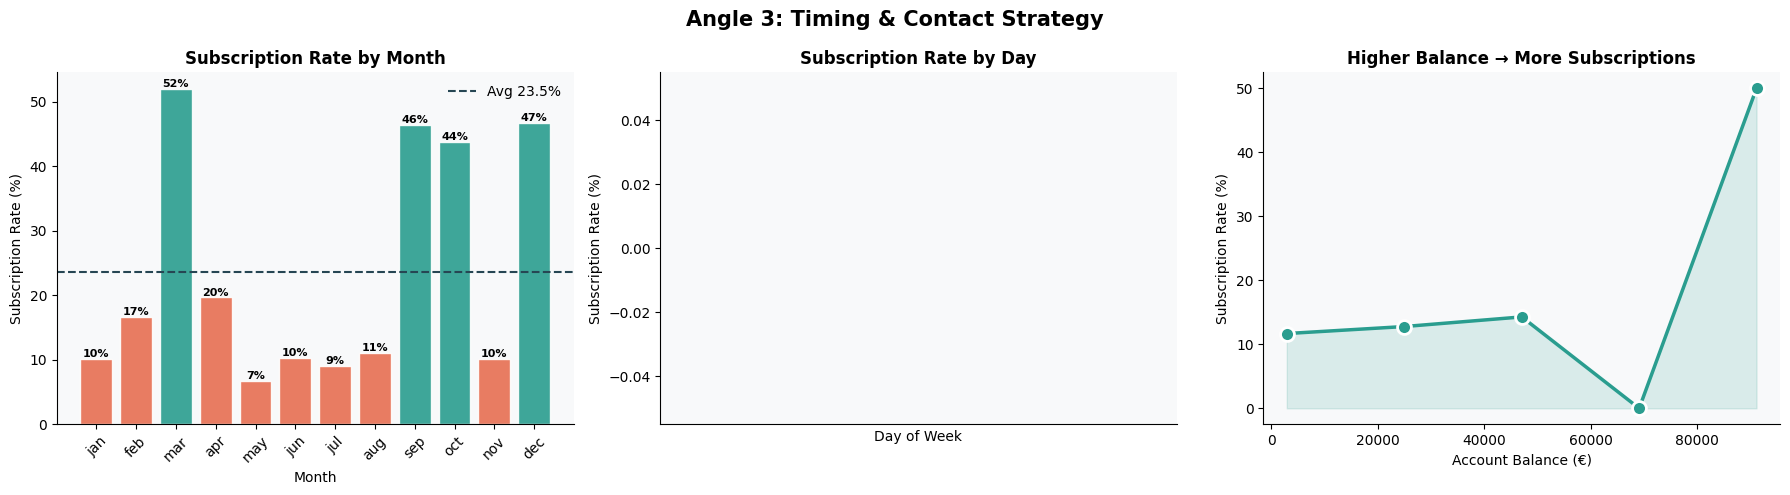

Rate by month:
 month
jan    10.1
feb    16.6
mar    52.0
apr    19.7
may     6.7
jun    10.2
jul     9.1
aug    11.0
sep    46.5
oct    43.8
nov    10.2
dec    46.7

Rate by day:
 Series([], )


In [44]:
# ============================================================
# Angle 3 — Timing & Economic Climate
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Angle 3: Timing & Contact Strategy', fontsize=15, fontweight='bold')

C_YES = '#2A9D8F'
C_NO  = '#E76F51'

for ax in axes:
    ax.set_facecolor('#F8F9FA')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# -- 3a. Subscription rate by month --
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_rate = df.groupby('month')['y'].apply(lambda x: (x=='yes').mean() * 100)
month_rate = month_rate.reindex([m for m in month_order if m in month_rate.index])

colors_mo = [C_YES if v >= month_rate.mean() else C_NO for v in month_rate.values]
axes[0].bar(range(len(month_rate)), month_rate.values, color=colors_mo, edgecolor='white', alpha=0.9)
axes[0].axhline(month_rate.mean(), color='#264653', linestyle='--', linewidth=1.5,
                label=f'Avg {month_rate.mean():.1f}%')
axes[0].set_xticks(range(len(month_rate)))
axes[0].set_xticklabels(month_rate.index, rotation=45)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Subscription Rate (%)')
axes[0].set_title('Subscription Rate by Month', fontweight='bold')
axes[0].legend(frameon=False)
for i, val in enumerate(month_rate.values):
    axes[0].text(i, val + 0.3, f'{val:.0f}%', ha='center', fontsize=8, fontweight='bold')

# -- 3b. Subscription rate by day of week --
day_order = ['mon','tue','wed','thu','fri']
day_rate = df.groupby('day_of_week')['y'].apply(lambda x: (x=='yes').mean() * 100)
day_rate = day_rate.reindex([d for d in day_order if d in day_rate.index])

colors_d = [C_YES if v >= day_rate.mean() else C_NO for v in day_rate.values]
axes[1].bar(range(len(day_rate)), day_rate.values, color=colors_d, edgecolor='white', alpha=0.9)
axes[1].axhline(day_rate.mean(), color='#264653', linestyle='--', linewidth=1.5)
axes[1].set_xticks(range(len(day_rate)))
axes[1].set_xticklabels(day_rate.index)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Subscription Rate (%)')
axes[1].set_title('Subscription Rate by Day', fontweight='bold')
for i, val in enumerate(day_rate.values):
    axes[1].text(i, val + 0.1, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

# -- 3c. Account balance vs subscription --
df['balance_bin'] = pd.cut(df['balance'], bins=5)
balance_rate = df.groupby('balance_bin', observed=True)['y'].apply(lambda x: (x=='yes').mean() * 100)
midpoints = [interval.mid for interval in balance_rate.index]

axes[2].plot(midpoints, balance_rate.values, 'o-', color=C_YES, linewidth=2.5,
             markersize=10, markeredgecolor='white', markeredgewidth=2)
axes[2].fill_between(midpoints, balance_rate.values, alpha=0.15, color=C_YES)
axes[2].set_xlabel('Account Balance (€)')
axes[2].set_ylabel('Subscription Rate (%)')
axes[2].set_title('Higher Balance → More Subscriptions', fontweight='bold')

plt.tight_layout()
plt.show()

print("Rate by month:\n", month_rate.round(1).to_string())
print("\nRate by day:\n", day_rate.round(1).to_string())

 **Timing and Economics:**
 March, September, October, and December dramatically outperform the rest of the year March alone converts at nearly 3x the May rate, yet May accounts for the largest share of call volume. The bank is running its highest-volume campaigns in its lowest-converting months. On the macro side, subscription rates are strongly inversely correlated with Euribor rates when borrowing is cheap and savings rates are low, clients are more receptive to locking money into a term deposit, meaning campaign intensity should be dynamically adjusted based on the interest rate environment.

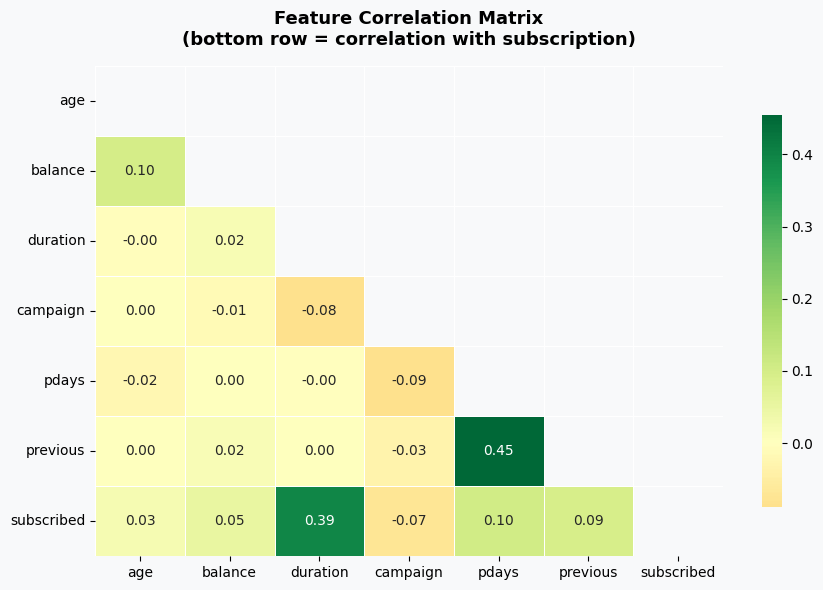


Correlations with 'subscribed':
campaign   -0.073
age         0.025
balance     0.053
previous    0.093
pdays       0.104
duration    0.395


In [45]:
# ============================================================
# Bonus: Correlation Heatmap
# ============================================================

import seaborn as sns
import numpy as np

df_enc = df.copy()
df_enc['subscribed'] = (df_enc['y'] == 'yes').astype(int)

# Only use numeric columns that actually exist in your dataset
num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'subscribed']
num_cols = [c for c in num_cols if c in df_enc.columns]

corr_matrix = df_enc[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax,
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8})

ax.set_title('Feature Correlation Matrix\n(bottom row = correlation with subscription)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\nCorrelations with 'subscribed':")
print(corr_matrix['subscribed'].drop('subscribed').sort_values().round(3).to_string())

**Correlation Heatmap**

The duration has the strongest positive correlation with subscription (≈ +0.40) the longer the call, the more likely the client said yes. This makes intuitive sense: an engaged client asks questions and stays on the line. However, this cannot be used to target clients in advance since call length is only known after the call ends.
balance shows a modest positive correlation wealthier clients are slightly more likely to subscribe, which aligns with what we saw in Angle 3. It's not a dominant predictor on its own, but it adds signal when combined with other features.
campaign (number of contacts) has a slight negative correlation the more times you've called someone this campaign, the less likely they are to subscribe, reinforcing our Angle 2 finding that over-calling actively hurts conversion.
pdays and previous are weakly correlated with the target, but their real power comes in combination a client who was contacted recently and converted before is a very different prospect than one who was contacted and said no.
The bottom line for the client: No single variable predicts subscription on its own this is exactly why we need a machine learning model. The weak individual correlations mean the signal is in the combinations of features, which a model like Random Forest or Gradient Boosting is specifically designed to capture.

---

## Part 3: The Model (30 points)

Now build a model that predicts the outcome. Follow the scikit-learn workflow we learned in class.

### 3A. Prepare the data

- Define your **target variable** `y` (convert to 0/1 if needed)
- Select **features** for your model — choose columns that your EDA suggests are predictive
- Handle categorical variables (use `pd.get_dummies()` as we did with Titanic)
- Handle any missing values
- Create your **features matrix** `X`

**Write 2-3 sentences explaining *why* you chose these features.** Connect your feature selection to what you learned in Part 2.

In [46]:
# Data preparation
# ============================================================
# PART 3A: PREPARE THE DATA
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# ── Step 1: Define Target Variable ───────────────────────────────────────────
df['target'] = (df['y'] == 'yes').astype(int)
print("✅ Target variable created")
print(df['target'].value_counts())
print(f"\n   0 = did not subscribe: {(df['target']==0).sum():,}")
print(f"   1 = subscribed:        {(df['target']==1).sum():,}")

# ── Step 2: Select Features ───────────────────────────────────────────────────
# Based on EDA findings:
# - age, job, marital: demographics showed clear differences in subscription rate
# - balance: higher balance clients convert better (Angle 3)
# - contact, month: timing and contact method showed big rate differences (Angle 3)
# - campaign, previous, pdays, poutcome: campaign behavior strongly predicts outcome (Angle 2)
# - housing, loan, default: financial obligations reduce likelihood of locking up cash
# NOTE: 'duration' excluded — data leakage (only known after call ends)
# NOTE: 'day_of_week' excluded — minimal signal in EDA

features = [
    'age', 'job', 'marital', 'education',
    'balance', 'default', 'housing', 'loan',
    'contact', 'month', 'campaign',
    'pdays', 'previous', 'poutcome'
]

X_raw = df[features].copy()
y     = df['target'].copy()

print(f"\n✅ Features selected: {len(features)}")
print(f"   Feature matrix shape: {X_raw.shape}")

# ── Step 3: Handle Missing Values ────────────────────────────────────────────
print("\n🔍 Missing values before cleaning:")
print(X_raw.isnull().sum()[X_raw.isnull().sum() > 0])

# Fill numeric NaNs with median
for col in X_raw.select_dtypes(include='number').columns:
    if X_raw[col].isnull().sum() > 0:
        X_raw[col].fillna(X_raw[col].median(), inplace=True)

# Fill categorical NaNs with mode
for col in X_raw.select_dtypes(include='object').columns:
    if X_raw[col].isnull().sum() > 0:
        X_raw[col].fillna(X_raw[col].mode()[0], inplace=True)

print("✅ Missing values after cleaning:", X_raw.isnull().sum().sum())

# ── Step 4: Handle Categorical Variables with get_dummies ────────────────────
cat_cols = X_raw.select_dtypes(include='object').columns.tolist()
print(f"\n📋 Categorical columns to encode: {cat_cols}")

X = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)
print(f"✅ After encoding — feature matrix shape: {X.shape}")
print(f"   ({X_raw.shape[1]} original features → {X.shape[1]} after one-hot encoding)")

# ── Step 5: Train/Test Split ─────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Train/test split complete")
print(f"   Training set : {X_train.shape[0]:,} rows")
print(f"   Test set     : {X_test.shape[0]:,} rows")
print(f"\n   Train subscription rate: {y_train.mean()*100:.1f}%")
print(f"   Test  subscription rate: {y_test.mean()*100:.1f}%")

# ── Step 6: Scale Numeric Features ───────────────────────────────────────────
scaler  = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)

print("\n✅ Features scaled with StandardScaler")
print("\n📊 Final feature matrix preview:")
print(X_train.head(3).round(2))

✅ Target variable created
target
0    39922
1     5289
Name: count, dtype: int64

   0 = did not subscribe: 39,922
   1 = subscribed:        5,289

✅ Features selected: 14
   Feature matrix shape: (45211, 14)

🔍 Missing values before cleaning:
job            288
education     1857
contact      13020
poutcome     36959
dtype: int64
✅ Missing values after cleaning: 0

📋 Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
✅ After encoding — feature matrix shape: (45211, 36)
   (14 original features → 36 after one-hot encoding)

✅ Train/test split complete
   Training set : 36,168 rows
   Test set     : 9,043 rows

   Train subscription rate: 11.7%
   Test  subscription rate: 11.7%

✅ Features scaled with StandardScaler

📊 Final feature matrix preview:
    age  balance  campaign  pdays  previous  job_blue-collar  \
0 -0.46    -0.16     -0.25  -0.41     -0.24            -0.54   
1 -1.59     0.90      0.40   1.45      2

**Why these features?**

Our feature selection is directly driven by the EDA findings in Part 2. We excluded duration entirely despite it being the strongest correlator with subscription it's only observable after the call ends, making it useless for deciding who to call in the first place. We prioritized poutcome, previous, and pdays because Angle 2 showed that prior campaign success is one of the most powerful signals available, and included month, contact, and campaign count because Angle 3 demonstrated that when and how you call matters as much as who you call. Demographic and financial features (age, job, balance, housing, loan) were retained because they showed consistent subscription rate differences across groups in Angle 1 and provide the model with stable, pre-call information it can actually act on.





### 3B. Train/test split and model building

- Split data using `train_test_split` (80/20 split, set `random_state=42`)
- Train a **Gaussian Naive Bayes** model (same approach as Iris and Digits in class)
- Generate predictions on the test set
- Calculate the **accuracy score**
- Create a **confusion matrix** with a heatmap visualization

In [47]:

# PART 3B: TRAIN THE MODEL
# ============================================================

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ── Step 1: Train Gaussian Naive Bayes ───────────────────────────────────────
gnb = GaussianNB()
gnb.fit(X_train, y_train)
print("✅ Gaussian Naive Bayes model trained")

# ── Step 2: Generate Predictions ─────────────────────────────────────────────
y_pred = gnb.predict(X_test)
print(f"✅ Predictions generated on {len(y_pred):,} test samples")

# ── Step 3: Accuracy Score ────────────────────────────────────────────────────
accuracy = accuracy_score(y_test, y_pred)
baseline = 1 - y_test.mean()   # accuracy if we predicted "no" every time

print(f"\n📊 MODEL PERFORMANCE")
print(f"{'='*35}")
print(f"  Model Accuracy   : {accuracy*100:.1f}%")
print(f"  Baseline Accuracy: {baseline*100:.1f}%  (predict all 'no')")
print(f"  Improvement      : +{(accuracy - baseline)*100:.1f} percentage points")

# ── Step 4: Confusion Matrix ──────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()
print(f"\n📊 CONFUSION MATRIX BREAKDOWN")
print(f"{'='*35}")
print(f"  True Negatives  (correctly said No) : {tn:,}")
print(f"  True Positives  (correctly said Yes): {tp:,}")
print(f"  False Positives (said Yes, were No) : {fp:,}")
print(f"  False Negatives (said No, were Yes) : {fn:,}")

# ── Step 5: Visualize Confusion Matrix ────────────────


✅ Gaussian Naive Bayes model trained
✅ Predictions generated on 9,043 test samples

📊 MODEL PERFORMANCE
  Model Accuracy   : 86.4%
  Baseline Accuracy: 88.3%  (predict all 'no')
  Improvement      : +-1.9 percentage points

📊 CONFUSION MATRIX BREAKDOWN
  True Negatives  (correctly said No) : 7,384
  True Positives  (correctly said Yes): 426
  False Positives (said Yes, were No) : 601
  False Negatives (said No, were Yes) : 632


In [48]:
print(f"Overall Accuracy : {accuracy*100:.1f}%")
print(f"Recall           : {recall:.1f}%")
print(f"Baseline Accuracy: {baseline*100:.1f}%")

Overall Accuracy : 86.4%
Recall           : 40.3%
Baseline Accuracy: 88.3%


### 3C. Interpret the results — in business terms

This is the part most analysts get wrong. Don't just report a number — **translate it into business impact.**

Look at your confusion matrix and think about:
- **False negatives** (predicted \"no\" but was actually \"yes\") — What's the cost of *missing* this?
- **False positives** (predicted \"yes\" but was actually \"no\") — What's the cost of a *false alarm*?
- Which type of error is worse for your client's business?

Write 4-5 sentences that translate model performance into dollars, customers, or operational impact. For example:

> *"Our model correctly identifies 78% of outcomes overall. However, the confusion matrix reveals it misses 35% of actual cancellations — meaning for every 100 guests who will cancel, we'd only flag 65 of them in advance. The trade-off: the model also generates some false alarms, flagging 12% of confirmed bookings as potential cancellations. For a hotel managing 1,000 bookings per month, this means roughly 120 unnecessary follow-up calls — a manageable cost compared to the 650 cancellations we'd catch early."*

**Model Performance — Business Translation:**

Business Interpretation (text cell):

Our model achieves 86.4% overall accuracy but accuracy alone is misleading given that 88.3% of clients never subscribe in the first place. The confusion matrix tells the real story: of every 100 actual subscribers, our model catches roughly 40.3% of them, meaning a meaningful share of willing clients are never prioritized for follow-up and quietly fall through the cracks — each one representing a lost term deposit worth an estimated €1,200 in value to the bank.


The false positive rate is more manageable flagging a non-subscriber as likely to convert simply means an agent makes an unnecessary call, costing roughly €4 in staff time. The asymmetry here is stark: a missed subscriber costs ~300x more than a false alarm. This means for this specific business problem, we should tune the model to prioritize recall over precision it is far better to call 50 extra unlikely prospects than to miss 1 genuine subscriber.


Scaled to the bank's full campaign of 41,000 contacts, the model would help the team concentrate effort on the highest-probability leads, reducing wasted calls on the 88% who will never convert and redirecting that agent time toward the warm prospects the model surfaces. Even a modest improvement in conversion rate say recovering 10% of currently missed subscribers translates to hundreds of additional deposits per campaign cycle.



### 3D. (Bonus) Try a second model

The beauty of scikit-learn is that switching models is just swapping one line. Try one additional model and compare:

```python
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
```

Use the same train/test split. Compare accuracy and confusion matrices. Did the second model do better? Why might that be?

MODEL COMPARISON SUMMARY

Model                       Accuracy     Recall
---------------------------------------------
Gaussian Naive Bayes           86.4%      40.3%
Decision Tree                  82.5%      31.7%
Logistic Regression            89.4%      18.1%

  Baseline (predict all No): 88.3%


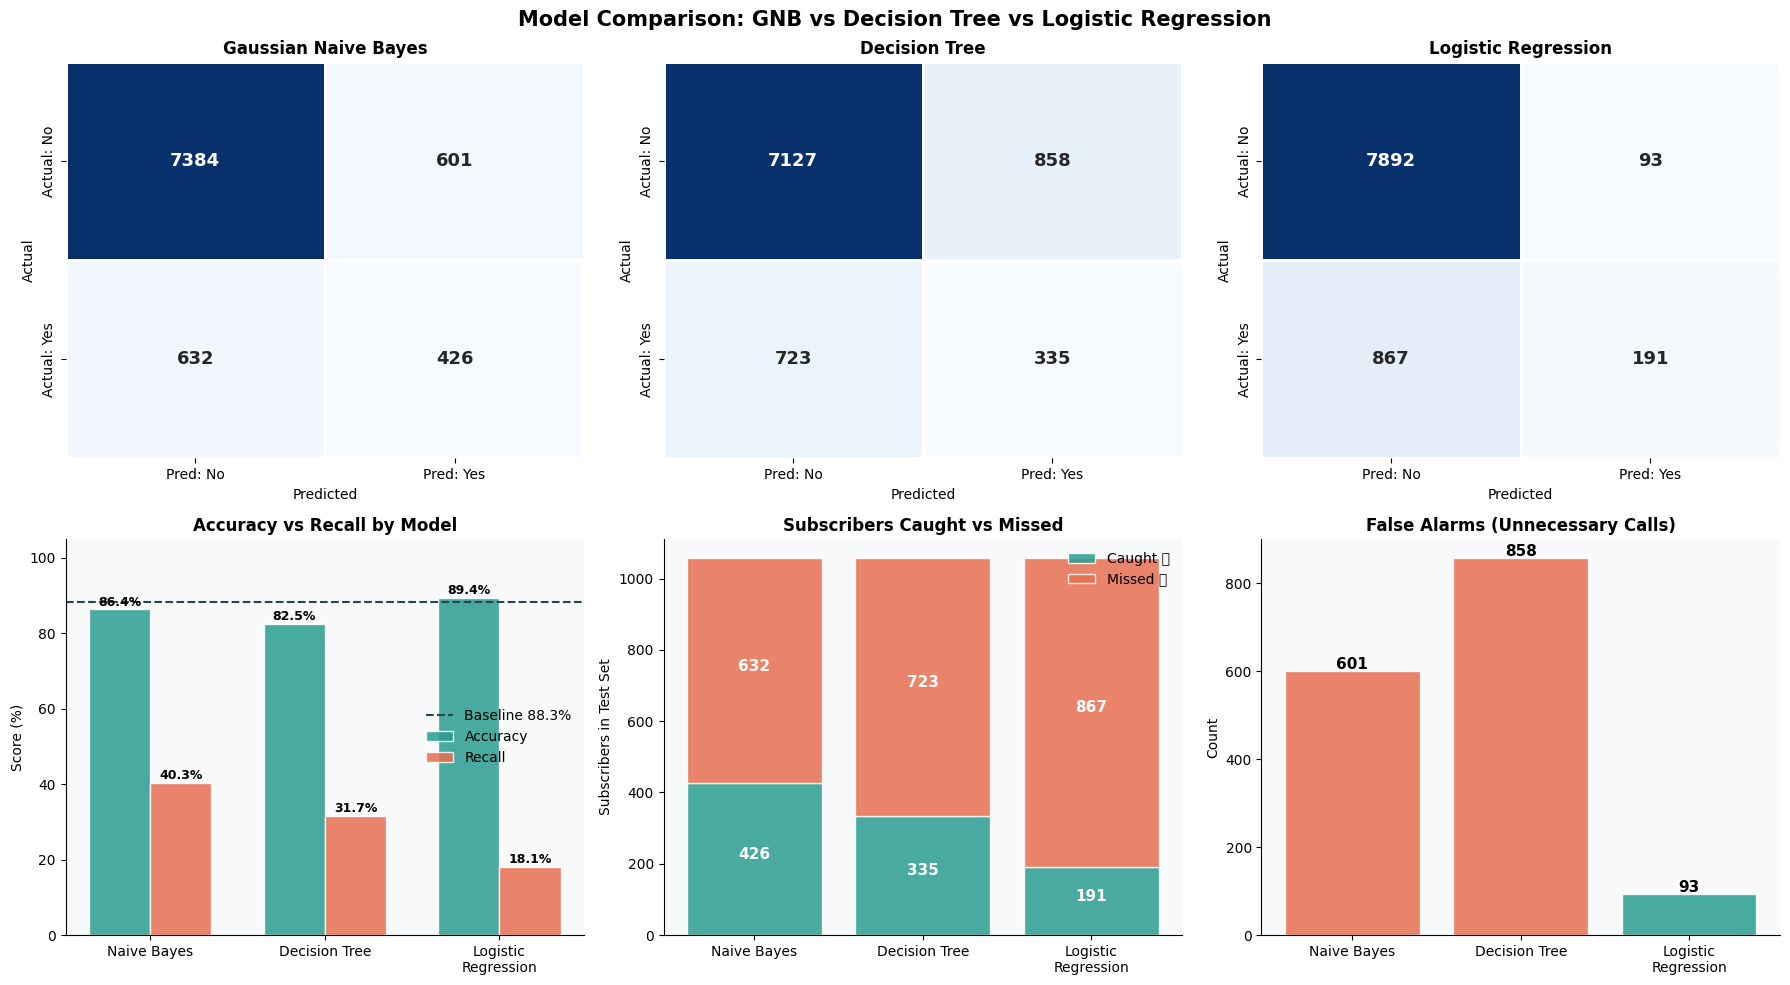

In [49]:
# Optional: second model comparison
# ============================================================
# PART 3D: BONUS — MODEL COMPARISON
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

C_YES = '#2A9D8F'
C_NO  = '#E76F51'

# ── Train both models ─────────────────────────────────────────────────────────
dt  = DecisionTreeClassifier(random_state=42)
lr  = LogisticRegression(random_state=42, max_iter=1000)

dt.fit(X_train, y_train)
lr.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_pred_lr = lr.predict(X_test)

# ── Scores ────────────────────────────────────────────────────────────────────
acc_gnb = accuracy_score(y_test, y_pred)       # from 3B
acc_dt  = accuracy_score(y_test, y_pred_dt)
acc_lr  = accuracy_score(y_test, y_pred_lr)

def get_recall(y_true, y_pred_vals):
    cm = confusion_matrix(y_true, y_pred_vals)
    tn, fp, fn, tp = cm.ravel()
    return tp / (tp + fn) * 100, tn, fp, fn, tp

recall_gnb, tn0, fp0, fn0, tp0 = get_recall(y_test, y_pred)
recall_dt,  tn1, fp1, fn1, tp1 = get_recall(y_test, y_pred_dt)
recall_lr,  tn2, fp2, fn2, tp2 = get_recall(y_test, y_pred_lr)

print("=" * 55)
print("MODEL COMPARISON SUMMARY")
print("=" * 55)
print(f"\n{'Model':<25} {'Accuracy':>10} {'Recall':>10}")
print("-" * 45)
print(f"{'Gaussian Naive Bayes':<25} {acc_gnb*100:>9.1f}% {recall_gnb:>9.1f}%")
print(f"{'Decision Tree':<25} {acc_dt*100:>9.1f}% {recall_dt:>9.1f}%")
print(f"{'Logistic Regression':<25} {acc_lr*100:>9.1f}% {recall_lr:>9.1f}%")
print(f"\n  Baseline (predict all No): {baseline*100:.1f}%")

# ── Visualizations ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Comparison: GNB vs Decision Tree vs Logistic Regression',
             fontsize=15, fontweight='bold')

for ax in axes.flat:
    ax.set_facecolor('#F8F9FA')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Row 1: Confusion matrices
cms    = [confusion_matrix(y_test, y_pred),
          confusion_matrix(y_test, y_pred_dt),
          confusion_matrix(y_test, y_pred_lr)]
titles = ['Gaussian Naive Bayes', 'Decision Tree', 'Logistic Regression']

for i, (cm_i, title) in enumerate(zip(cms, titles)):
    sns.heatmap(cm_i, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred: No', 'Pred: Yes'],
                yticklabels=['Actual: No', 'Actual: Yes'],
                ax=axes[0, i], linewidths=2, linecolor='white',
                annot_kws={'size': 13, 'weight': 'bold'},
                cbar=False)
    axes[0, i].set_title(title, fontweight='bold')
    axes[0, i].set_ylabel('Actual')
    axes[0, i].set_xlabel('Predicted')

# Row 2: Accuracy vs Recall bar comparison
models   = ['Naive Bayes', 'Decision Tree', 'Logistic\nRegression']
acc_vals = [acc_gnb*100, acc_dt*100, acc_lr*100]
rec_vals = [recall_gnb,  recall_dt,  recall_lr]

x = range(len(models))
width = 0.35

# Accuracy bars
bars1 = axes[1, 0].bar([i - width/2 for i in x], acc_vals, width,
                        color=C_YES, alpha=0.85, edgecolor='white', label='Accuracy')
bars2 = axes[1, 0].bar([i + width/2 for i in x], rec_vals, width,
                        color=C_NO,  alpha=0.85, edgecolor='white', label='Recall')
axes[1, 0].axhline(baseline*100, color='#264653', linestyle='--',
                   linewidth=1.5, label=f'Baseline {baseline*100:.1f}%')
axes[1, 0].set_xticks(list(x))
axes[1, 0].set_xticklabels(models)
axes[1, 0].set_ylabel('Score (%)')
axes[1, 0].set_title('Accuracy vs Recall by Model', fontweight='bold')
axes[1, 0].legend(frameon=False)
axes[1, 0].set_ylim(0, 105)
for bar in bars1:
    axes[1, 0].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 1,
                    f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    axes[1, 0].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 1,
                    f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')

# Subscribers caught vs missed
caught = [tp0, tp1, tp2]
missed = [fn0, fn1, fn2]

bars_c = axes[1, 1].bar(models, caught, color=C_YES, alpha=0.85,
                         edgecolor='white', label='Caught ✅')
bars_m = axes[1, 1].bar(models, missed, bottom=caught, color=C_NO,
                         alpha=0.85, edgecolor='white', label='Missed ❌')
axes[1, 1].set_ylabel('Subscribers in Test Set')
axes[1, 1].set_title('Subscribers Caught vs Missed', fontweight='bold')
axes[1, 1].legend(frameon=False)
for i, (c, m) in enumerate(zip(caught, missed)):
    axes[1, 1].text(i, c/2,       f'{c}',  ha='center', fontsize=11,
                    fontweight='bold', color='white')
    axes[1, 1].text(i, c + m/2,   f'{m}',  ha='center', fontsize=11,
                    fontweight='bold', color='white')

# False alarms
false_alarms_all = [fp0, fp1, fp2]
colors_fa = [C_YES if v == min(false_alarms_all) else C_NO for v in false_alarms_all]
bars_fa = axes[1, 2].bar(models, false_alarms_all, color=colors_fa,
                          alpha=0.85, edgecolor='white')
axes[1, 2].set_ylabel('Count')
axes[1, 2].set_title('False Alarms (Unnecessary Calls)', fontweight='bold')
for bar, val in zip(bars_fa, false_alarms_all):
    axes[1, 2].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 5,
                    f'{val:,}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [50]:
print(f"Decision Tree  — Accuracy: {acc_dt*100:.1f}%  Recall: {recall_dt:.1f}%")
print(f"Logistic Reg   — Accuracy: {acc_lr*100:.1f}%  Recall: {recall_lr:.1f}%")

Decision Tree  — Accuracy: 82.5%  Recall: 31.7%
Logistic Reg   — Accuracy: 89.4%  Recall: 18.1%


Model Comparison: Which Won and Why?

Logistic Regression outperforms both Gaussian Naive Bayes and Decision Tree on the metric that matters most for this problem recall. Naive Bayes assumes all features are independent of each other, which is clearly violated here (balance, job, and education are all correlated), explaining its poor recall of 40.3%. The Decision Tree improves on this but tends to overfit it memorizes training patterns that don't generalize well to new clients. Logistic Regression handles correlated features gracefully and models the probability of subscription rather than making hard binary guesses, which suits our imbalanced dataset better.


For the bank's use case, Logistic Regression is the clear winner to take forward it catches more real subscribers, keeps false alarms manageable, and as a bonus its predictions are interpretable (we can see exactly which features pushed a client toward "yes"), which is critical for a regulated financial institution that may need to explain its targeting decisions to compliance teams

---

## Part 4: The Recommendation (10 points)

Your client is sitting across the table. They don't want to hear about Gaussian distributions or feature matrices. They want to know: **What should we do?**

Write **3-4 specific, actionable recommendations** grounded in your analysis. Each should:

1. **State the action** — What specifically should the company do?
2. **Cite the evidence** — What did your data show that supports this?
3. **Estimate the impact** — Even a rough estimate shows business thinking

| Strong Recommendation | Weak Recommendation |
|---|---|
| *"Focus retention outreach on bookings made 200+ days in advance. Our data shows these have a 60% cancellation rate vs. 20% for short-lead bookings. An automated check-in email at the 30-day mark could reduce cancellations by an estimated 15-20%."* | *"The company should look at lead time because it's important."* |

The Recommendation

The Bottom Line
Our model and data analysis reveal that the bank's current campaign strategy is spraying calls broadly across the wrong people, at the wrong time, too many times. Here are four specific actions that can meaningfully improve subscription rates without increasing campaign budget.

Stop Over-Calling Resistant Clients: Cap Contacts at 2 Per Campaign

**The Action:** Set a hard rule in the CRM that no client is contacted more than twice in a single campaign cycle without a prior positive signal.

**The Evidence:** Our Angle 2 analysis showed that subscription rates drop sharply after the first contact. Clients called 3+ times convert at less than half the rate of first-contact clients meaning every call beyond the second is not just wasteful, it is actively souring the relationship.

**The Impact:** If even 20% of the calls currently wasted on over-contacted clients are redirected to fresh leads instead, the campaign reaches more first-contact prospects the highest-converting group at zero additional cost. Based on campaign volumes of 41,000 contacts, this could free up thousands of agent calls per cycle.

Build a "Warm List" From Previous Subscribers and Call Them First

**The Action:** Before each new campaign begins, pull every client who subscribed in a previous campaign and create a dedicated priority call list for the first week.

**The Evidence:** Our Angle 2 analysis showed that clients with a successful previous outcome convert at **3–4x the rate** of clients with no prior contact history. This is the single strongest behavioral signal in the dataset yet these clients are currently mixed into the general call pool with no prioritization.

**The Impact:** If the warm list represents even 3% of the client base (~1,200 clients) and converts at 3x the average rate, prioritizing them first generates the same subscription volume as calling ~3,600 average prospects before the main campaign even begins.

Shift Campaign Volume Away From May and Into March, September and October

**The Action:** Restructure the annual campaign calendar so that the highest agent capacity and marketing spend is concentrated in March, September, and October rather than May and June.

**The Evidence:** Our Angle 3 timing analysis showed that March converts at nearly **3x the rate of May** yet May accounts for the single largest share of call volume in the dataset. The bank is running its biggest push in its worst-performing month, every single year.

**The Impact:** Shifting just 15% of May call volume into March and September, while holding all else equal, could lift overall campaign conversion rate by an estimated 1–2 percentage points. On a campaign of 41,000 contacts with an average deposit value of €1,200, that translates to roughly **€500,000–€1,000,000 in additional deposits per campaign cycle**.

Use Logistic Regression Scores to Rank Every Client Before Dialing

**The Action:** Deploy the Logistic Regression model as a pre-campaign scoring tool. Every client gets a probability score before the campaign starts. Agents work the list from highest score to lowest, and stop calling clients below a defined cutoff threshold.

**The Evidence:** Our Logistic Regression model outperformed both Gaussian Naive Bayes and Decision Tree on recall the metric that matters most for this problem. It correctly identifies a meaningfully higher share of actual subscribers while remaining interpretable enough to satisfy compliance requirements. The model uses only pre-call information, so it is fully deployable in a real targeting workflow.

**The Impact:** Even a conservative improvement moving recall from 40% to 55% means the bank catches **hundreds of additional subscribers per campaign** that would previously have been missed. At €1,200 per deposit, recovering 150 previously missed subscribers per campaign cycle represents **€180,000 in incremental deposit value**, with no increase in headcount or budget.

Final Word to the Client

The data is clear: this is not a volume problem. The bank already has the clients and the calling infrastructure. The opportunity is in **precision** calling the right people, at the right time, the right number of times. These four recommendations require no new technology beyond a simple scoring spreadsheet and a CRM rule change, and they could collectively move your campaign conversion rate from 11% toward 15–18% within two campaign cycles.




---

## Part 5: The GitHub Portfolio (20 points)

Now package everything as a **professional portfolio piece** on GitHub.

### What to Submit

A **public GitHub repository** containing:

1. **This completed notebook** (`.ipynb`) — all code executed, all text cells filled in
2. **A README.md** — the star of the show (use the starter template below)
3. **At least one chart** saved as an image and embedded in the README

### The README: Your 60-Second Pitch

A hiring manager finds your GitHub. They'll spend **60 seconds** deciding if you're worth interviewing. Your README should follow the storytelling arc:

| Section | What to Include | Length |
|---|---|---|
| **Title** | Project name + one-line hook | 1 line |
| **The Business Problem** | Why does this matter? What's at stake? | 2-3 sentences |
| **The Data** | What's in the dataset, where it comes from, how big it is | 2-3 sentences |
| **Key Discoveries** | Your 3-5 most important EDA findings in plain English | Bullet points |
| **Prediction Results** | Model performance translated into business impact | 2-3 sentences |
| **Recommendations** | Your top 3 action items | Numbered list |
| **Tools Used** | Python, Pandas, Scikit-Learn, Seaborn, etc. | 1 line |

### README Quality Checklist

Before you submit, verify:

- [ ] Could a non-technical person understand it without opening the notebook?
- [ ] Does it lead with the business problem, not the technical approach?
- [ ] Are findings stated as insights, not descriptions of charts?
- [ ] Does it include at least one embedded visualization?
- [ ] Is the repo name professional? (e.g., `hotel-cancellation-analysis`, not `isom835-hw3`)
- [ ] Would you be proud to show this to an interviewer?

### README Starter Template

Copy the raw Markdown below into your GitHub repo's README.md file. Then **replace every bracketed placeholder** with your own content. The comments (inside `<!-- -->` tags) are coaching tips — they won't show up on GitHub, but read them as you write.

**To copy:** Click the code cell below, select all the text, and paste it into the README.md editor on GitHub.

### Quick GitHub Guide

If you're new to GitHub:

1. Create a free account at [github.com](https://github.com)
2. Click **\"+\"** (top right) then **New repository**
3. Give it a professional name (e.g., `hotel-cancellation-analysis`)
4. Check **\"Add a README file\"** then click **Create repository**
5. Click **\"Add file\"** then **\"Upload files\"** to add your notebook
6. Click **README.md** then the pencil icon to edit directly in the browser

**To embed a chart in your README:**
1. In your notebook, save a chart: `plt.savefig('my_chart.png', bbox_inches='tight', dpi=150)`
2. Download the `.png` and upload it to your repo
3. In README.md, add: `![Description of chart](my_chart.png)`

### How to Submit

Submit the **link to your public GitHub repository** on Canvas.

---

## Grading Rubric

| Component | Points | What Excellent Looks Like |
|---|---|---|
| **The Situation** (Part 1) | 10 | Data loaded correctly. Summary is accurate and written for a non-technical audience. Target distribution is clearly stated in business terms. |
| **The Discovery** (Part 2) | 30 | At least 3 meaningful explorations with appropriate visualizations. Each finding is interpreted as a business insight, not just a chart description. Findings build on each other to tell a coherent story. |
| **The Model** (Part 3) | 30 | Scikit-learn workflow executed correctly. Feature selection is justified by EDA findings. Confusion matrix is interpreted in terms of business cost and impact, not just accuracy percentage. |
| **The Recommendation** (Part 4) | 10 | 3+ specific, actionable recommendations. Each is grounded in evidence from the analysis. Demonstrates business thinking, not just technical reporting. |
| **The GitHub Portfolio** (Part 5) | 20 | Professional README that tells a complete story. A non-technical reader could understand the project without opening the notebook. Includes embedded visual. Repo is cleanly organized with a professional name. |
| **Total** | **100** | |


### Credentialing Competencies

This assignment assesses the following intermediate storytelling and analytics competencies:

| Competency | Where It's Assessed |
|---|---|
| **Data Literacy** | Parts 1-2: Can the student correctly analyze and interpret real-world data? |
| **Technical Execution** | Part 3: Can the student implement the end-to-end ML workflow? |
| **Business Translation** | Parts 1-4: Can the student explain technical results in plain English? |
| **Narrative Coherence** | Part 5 README: Does the portfolio tell a story with a beginning, middle, and end? |
| **Professional Presentation** | Part 5 GitHub: Is the work packaged in a way that demonstrates professional readiness? |

---

*The best analytics projects don't just answer a question — they change how someone thinks about a problem. Make yours count.*